# SO3LR-SF Python API Examples

This notebook demonstrates the complete Python API for SO3LR-SF, covering:

1. **Single Point Calculation** - Basic energy calculation
2. **Structure Trimming** - Reducing protein size around ligands
3. **Optimization with Constraints** - Structure optimization with selective flexibility
4. **Energy Decomposition Analysis (EDA)** - Component-wise energy breakdown
5. **Explainability** - Per-atom energy contributions with heatmaps
6. **Protein-Ligand Explainability** - Enhanced visualization with interaction fingerprints

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import SO3LR-SF modules
from src.calculator import So3lrSfCalculator
from src.interaction_energy import protein_ligand_interaction
from src.structure_ops import trim_structure, optimize_structure, create_optimization_constraint
from src.molecule_loader import load_ase_structure

# Setup paths to test data
protein_path = "tests/test_data/2CET_prot.xyz"
protein_path_pdb = protein_path.replace(".xyz", ".pdb")

ligand_path = "tests/test_data/2CET_lig.xyz"

/home/hamza/.cache/pypoetry/virtualenvs/so3lr-sf-nvxEypVy-py3.12/lib/python3.12/site-packages/prolif/datafiles.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/hamza/.cache/pypoetry/virtualenvs/so3lr-sf-nvxEypVy-py3.12/lib/python3.12/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


In [2]:
# Initialize calculators
calc = So3lrSfCalculator()
eda_calc = So3lrSfCalculator(output_per_atom_energy_components=True)


MLFF:root:Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.
MLFF:root:Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.


## 1. Single Point Calculation (End Point Calculation)

Calculate protein-ligand interaction energy for single molecules or all molecules in multi-structure files.

In [ ]:

print("=== SINGLE POINT CALCULATION (END POINT CALCULATION) ===")

# Example 1: Single molecule calculation
print(f"Protein: {protein_path}")
print(f"Ligand: {ligand_path}")

interaction_energy = protein_ligand_interaction(
    protein_path=protein_path,
    ligand_path=ligand_path, 
    calc=calc,
    verbose=True
)

print(f"Interaction energy: {interaction_energy:.6f} eV")
print(f"Binding energy: {interaction_energy * 23.06:.2f} kcal/mol")

## 2. Structure Trimming

#### a. Reduce protein size by keeping only **atoms (using XYZ format)** within a defined radius

In [3]:
print("\n=== STRUCTURE TRIMMING ===")

# Load original protein to see size
original_protein = load_ase_structure(protein_path)[0]
print(f"Original protein atoms: {len(original_protein)}")

# Trim protein around ligand (8 Angstrom radius)
trimmed_protein_path = trim_structure(
    protein_path=protein_path,
    ligand_path=ligand_path,
    radius=4.0,
    output_dir="trimming_example"
)

# Load trimmed protein to see size reduction
trimmed_protein = load_ase_structure(trimmed_protein_path)[0]
print(f"Trimmed protein atoms: {len(trimmed_protein)}")
print(f"Size reduction: {len(original_protein) - len(trimmed_protein)} atoms")
print(f"Trimmed protein saved to: {trimmed_protein_path}")

# Calculate interaction energy with trimmed protein
trimmed_interaction = protein_ligand_interaction(
    protein_path=trimmed_protein_path,
    ligand_path=ligand_path,
    calc=calc
)

print(f"\nInteraction energies:")
print(f"  Original protein: {interaction_energy:.6f} eV")
print(f"  Trimmed protein:  {trimmed_interaction:.6f} eV")
print(f"  Difference:       {abs(interaction_energy - trimmed_interaction):.6f} eV")

10-30 17:42:32 - WARNING - Using atom-based trimming for .XYZ file: 2CET_prot.xyz
10-30 17:42:32 - WARNING - Individual atoms will be trimmed - residues may be incomplete!
10-30 17:42:32 - WARNING - For complete residue trimming, use PDB format input files
10-30 17:42:32 - INFO - Trimmed protein (117 atoms from 281 original atoms) saved to: tests/test_data/2CET_prot_trimmed_4.0A_atom.xyz
10-30 17:42:32 - INFO - Trimming method: atom-based
10-30 17:42:32 - INFO - Protein: tests/test_data/2CET_prot_trimmed_4.0A_atom.xyz
10-30 17:42:32 - INFO - Ligand: tests/test_data/2CET_lig.xyz
10-30 17:42:32 - INFO - Calculating non-interacting energy...
10-30 17:42:32 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:42:32 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.



=== STRUCTURE TRIMMING ===
Original protein atoms: 281
Trimmed protein atoms: 117
Size reduction: 164 atoms
Trimmed protein saved to: tests/test_data/2CET_prot_trimmed_4.0A_atom.xyz


10-30 17:42:34 - INFO - Calculating complex energy...
10-30 17:42:34 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:42:34 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.
10-30 17:42:36 - INFO - Interaction energy calculated: -5.161606 eV
10-30 17:42:36 - INFO - Binding energy: -119.0 kcal/mol



Interaction energies:
  Original protein: -7.156372 eV
  Trimmed protein:  -5.161606 eV
  Difference:       1.994766 eV


b. Reduce protein size by keeping only **residues (using PDB format)** within a defined radius

In [4]:
print("\n=== STRUCTURE TRIMMING ===")

# Load original protein to see size
original_protein = load_ase_structure(protein_path_pdb)[0]
print(f"Original protein atoms: {len(original_protein)}")

# Trim protein around ligand (8 Angstrom radius)
trimmed_protein_path = trim_structure(
    protein_path=protein_path_pdb,
    ligand_path=ligand_path,
    radius=2.0,
)

# Load trimmed protein to see size reduction
trimmed_protein = load_ase_structure(trimmed_protein_path)[0]
print(f"Trimmed protein atoms: {len(trimmed_protein)}")
print(f"Size reduction: {len(original_protein) - len(trimmed_protein)} atoms")
print(f"Trimmed protein saved to: {trimmed_protein_path}")

# Calculate interaction energy with trimmed protein
trimmed_interaction = protein_ligand_interaction(
    protein_path=trimmed_protein_path,
    ligand_path=ligand_path,
    calc=calc
)

print(f"\nInteraction energies:")
print(f"  Original protein: {interaction_energy:.6f} eV")
print(f"  Trimmed protein:  {trimmed_interaction:.6f} eV")
print(f"  Difference:       {abs(interaction_energy - trimmed_interaction):.6f} eV")

10-30 17:42:36 - INFO - Using residue-based trimming for PDB file: 2CET_prot.pdb
10-30 17:42:36 - INFO - Complete residues will be included if any atom is within the cutoff radius
10-30 17:42:36 - INFO - The attribute(s) types have already been read from the topology file. The guesser will only guess empty values for this attribute, if any exists. To overwrite it by completely guessed values, you can pass the attribute to the force_guess parameter instead of the to_guess one
10-30 17:42:36 - INFO - There is no empty types values. Guesser did not guess any new values for types attribute
10-30 17:42:36 - INFO - attribute masses has been guessed successfully.
/home/hamza/.cache/pypoetry/virtualenvs/so3lr-sf-nvxEypVy-py3.12/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:184: DeprecationWarning: `guess_atom_element` is deprecated!
`guess_atom_element` will be removed in release 3.0.0.
MDAnalysis.topology.guessers is deprecated in favour of the new Guessers API. See MDAnalysis.


=== STRUCTURE TRIMMING ===
Original protein atoms: 281
Trimmed protein atoms: 93
Size reduction: 188 atoms
Trimmed protein saved to: tests/test_data/2CET_prot_trimmed_2.0A_residue.pdb


10-30 17:42:39 - INFO - Calculating complex energy...
10-30 17:42:39 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:42:39 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.
10-30 17:42:41 - INFO - Interaction energy calculated: -7.636414 eV
10-30 17:42:41 - INFO - Binding energy: -176.1 kcal/mol



Interaction energies:
  Original protein: -7.156372 eV
  Trimmed protein:  -7.636414 eV
  Difference:       0.480042 eV


## 3. Structure Optimization with Constraints

Optimize molecular structures with selective flexibility based on distance from ligand.

In [5]:
print("\n=== STRUCTURE OPTIMIZATION WITH CONSTRAINTS ===")

# Load structures
protein_atoms = load_ase_structure(protein_path)[0]
ligand_atoms = load_ase_structure(ligand_path)[0]

# Create complex
complex_atoms = protein_atoms + ligand_atoms
n_protein_atoms = len(protein_atoms)

# Create constraint (only atoms within 5Å of ligand will be flexible)
constraint = create_optimization_constraint(
    complex_atoms=complex_atoms,
    n_protein_atoms=n_protein_atoms,
    opt_radius=5.0,
    protein_path=protein_path
)

# Optimize structure with constraints
optimized_path, opt_info = optimize_structure(
    atoms=complex_atoms,
    calc=calc,
    optimizer='FIRE',
    fmax=0.05,
    steps=50,
    output_path=Path("tests/test_data/2CET_cpx_optimized.xyz"),
    opt_radius=2.0,
    n_protein_atoms=n_protein_atoms,
    protein_path=protein_path
)

# Show constraint details
constraint_info = opt_info['constraint_info']
constraint_info

10-30 17:42:41 - WARNING - Using atom-level constraints for .XYZ file: 2CET_prot.xyz
10-30 17:42:41 - WARNING - Individual atoms will be constrained - residues may be split!
10-30 17:42:41 - WARNING - For complete residue constraints, use PDB format input files
10-30 17:42:41 - INFO - Optimization constraints (atom-based):
10-30 17:42:41 - INFO -   Flexible protein atoms: 180/281
10-30 17:42:41 - INFO -   Fixed protein atoms: 101
10-30 17:42:41 - INFO -   Ligand atoms (always flexible): 43
10-30 17:42:41 - INFO - Output path is already a file: tests/test_data/2CET_cpx_optimized.xyz, skipping optimization.



=== STRUCTURE OPTIMIZATION WITH CONSTRAINTS ===


{'constraint_applied': False, 'constraint_type': None}

## 4. Energy Decomposition Analysis (EDA)

Break down interaction energy into individual components (MLFF, Electrostatics, Dispersion, etc.).

In [ ]:
print("\n=== ENERGY DECOMPOSITION ANALYSIS (EDA) ===")

# Initialize calculator with per-atom components enabled

# Calculate interaction energy with EDA
interaction_energy, analysis = protein_ligand_interaction(
    protein_path=protein_path,
    ligand_path=ligand_path,
    calc=eda_calc,
    eda=True,
    verbose=True
)

print(f"\nTotal interaction energy: {interaction_energy:.6f} eV")
print(f"\n=== ENERGY COMPONENT BREAKDOWN ===")

# Display interaction energy components
if 'interaction_energy_components' in analysis:
    components = analysis['interaction_energy_components']
    print("\nInteraction energy components:")
    total_check = 0.0
    for component, energy in components.items():
        print(f"  {component:20s}: {energy:10.6f} eV ({energy*23.06:8.2f} kcal/mol)")
        total_check += energy
    
    print(f"  {'Total (sum)':20s}: {total_check:10.6f} eV ({total_check*23.06:8.2f} kcal/mol)")
    print(f"  {'Total (direct)':20s}: {interaction_energy:10.6f} eV ({interaction_energy*23.06:8.2f} kcal/mol)")

# Show complex, protein, and ligand component totals
for system_type in ['complex', 'protein', 'ligand']:
    key = f'{system_type}_energy_components'
    if key in analysis:
        print(f"\n{system_type.capitalize()} energy components:")
        for component, energy in analysis[key].items():
            print(f"  {component:20s}: {energy:10.6f} eV")

10-30 17:42:41 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:42:41 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.
10-30 17:42:41 - INFO - Protein: tests/test_data/2CET_prot.xyz
10-30 17:42:41 - INFO - Ligand: tests/test_data/2CET_lig.xyz
10-30 17:42:41 - INFO - Calculating non-interacting energy...
10-30 17:42:41 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:42:41 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.



=== ENERGY DECOMPOSITION ANALYSIS (EDA) ===


10-30 17:42:46 - INFO - Calculating complex energy...
10-30 17:42:46 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:42:46 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.
10-30 17:42:49 - INFO - Interaction energy calculated: -7.156372 eV
10-30 17:42:49 - INFO - Binding energy: -165.0 kcal/mol
10-30 17:42:49 - INFO - Computing Energy Decomposition Analysis...
10-30 17:42:49 - INFO - Energy Decomposition Analysis complete



Total interaction energy: -7.156372 eV

=== ENERGY COMPONENT BREAKDOWN ===

Interaction energy components:
  nn_energy           :  -5.528023 eV ( -127.48 kcal/mol)
  dispersion_energy   :  -1.589653 eV (  -36.66 kcal/mol)
  electrostatic_energy:  -0.038422 eV (   -0.89 kcal/mol)
  zbl_repulsion       :  -0.000316 eV (   -0.01 kcal/mol)
  Total (sum)         :  -7.156414 eV ( -165.03 kcal/mol)
  Total (direct)      :  -7.156372 eV ( -165.03 kcal/mol)

Complex energy components:
  nn_energy           : -585.350464 eV
  dispersion_energy   :  -7.299526 eV
  electrostatic_energy: -13.141303 eV
  zbl_repulsion       :  29.393694 eV

Protein energy components:
  nn_energy           : -504.668488 eV
  dispersion_energy   :  -5.068500 eV
  electrostatic_energy: -11.231137 eV
  zbl_repulsion       :  25.296520 eV

Ligand energy components:
  nn_energy           : -75.153954 eV
  dispersion_energy   :  -0.641374 eV
  electrostatic_energy:  -1.871744 eV
  zbl_repulsion       :   4.097490 eV


## 5. Ligand Explainability

Generate per-atom energy contributions and molecular heatmaps showing which atoms contribute most to binding.

10-30 17:42:49 - INFO - Protein: tests/test_data/2CET_prot.pdb
10-30 17:42:49 - INFO - Ligand: tests/test_data/2CET_lig.xyz
10-30 17:42:49 - INFO - Calculating non-interacting energy...
10-30 17:42:49 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:42:49 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.
10-30 17:42:51 - INFO - Calculating complex energy...
10-30 17:42:51 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:42:51 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.
10-30 17:42:53 - INFO - Interaction energy calculated:

Heatmap saved to: /home/hamza/github/so3lr-sf/tests/test_data/ligand_explain_heatmap.png


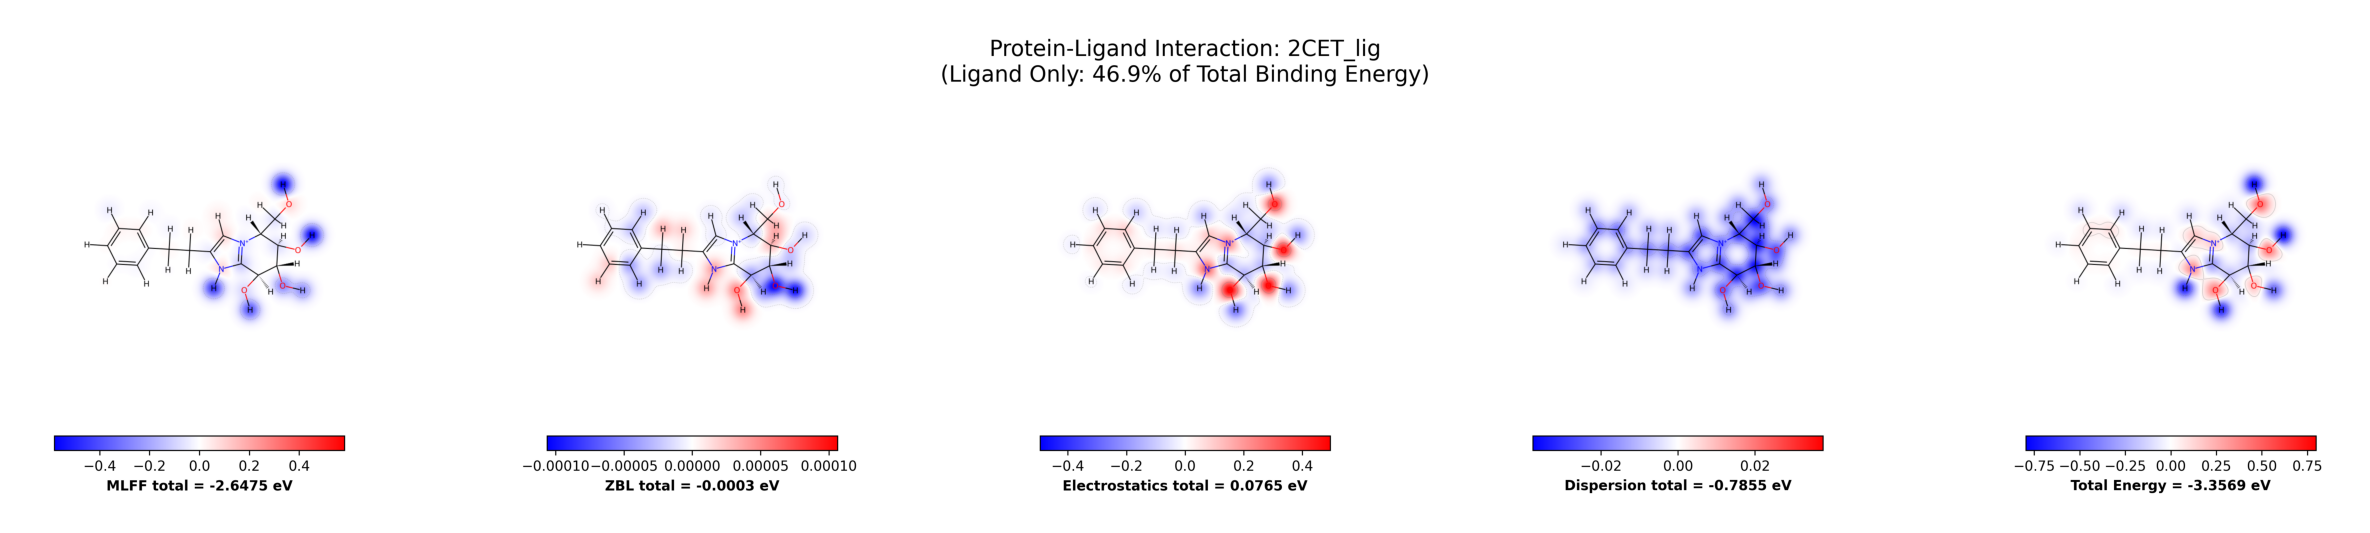

In [7]:
# Calculate interaction energy with enhanced explainability
ligand_heatmap_output = Path("tests/test_data/ligand_explain_heatmap.png")

interaction_energy, analysis = protein_ligand_interaction(
    protein_path=protein_path_pdb,
    ligand_path=ligand_path,
    calc=eda_calc,
    exp_outputs=(ligand_heatmap_output,None,None),
    verbose=True
)

print(f"Heatmap saved to: {ligand_heatmap_output.resolve()}")
# load the heatmap image and display it
img = plt.imread(ligand_heatmap_output)
plt.figure(figsize=(8, 6), dpi=300)   # width=8in, height=6in
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()


## 6. Protein-Ligand Explainability

Enhanced explainability with protein-ligand interaction fingerprints, showing both ligand contributions and interacting protein residues.

In [19]:
print("\n=== PROTEIN-LIGAND EXPLAINABILITY ===")

# First, we need to prepare protein data for protein-ligand explainability
from src.molecule_loader import load_molecule_to_prolif

# Load and prepare protein for ProLIF analysis

protein_path_pdb = Path('tests/test_data/2CET_prot.pdb')
preloaded_protein_prolif = load_molecule_to_prolif(protein_path_pdb)

pl_2d_heatmap_output = Path("tests/test_data/protein_ligand_2d_heatmap.png")

interaction_energy, analysis = protein_ligand_interaction(
    protein_path=protein_path_pdb,
    ligand_path=ligand_path,
    calc=eda_calc,
    exp_outputs=(None, pl_2d_heatmap_output, None),
    preloaded_protein_prolif=preloaded_protein_prolif,
    verbose=True
)

img = plt.imread(pl_2d_heatmap_output)
plt.figure(figsize=(8, 6), dpi=300)   # width=8in, height=6in
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

10-30 17:50:44 - INFO - Protein: tests/test_data/2CET_prot.pdb
10-30 17:50:44 - INFO - Ligand: tests/test_data/2CET_lig.xyz
10-30 17:50:44 - INFO - Calculating non-interacting energy...
10-30 17:50:44 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:50:44 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.



=== PROTEIN-LIGAND EXPLAINABILITY ===


10-30 17:50:46 - INFO - Calculating complex energy...
10-30 17:50:46 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:50:46 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.
10-30 17:50:48 - INFO - Interaction energy calculated: -7.156372 eV
10-30 17:50:48 - INFO - Binding energy: -165.0 kcal/mol
10-30 17:50:48 - INFO - Starting explainability analysis...
10-30 17:50:48 - INFO - Generating explainability heatmap ...
10-30 17:50:48 - INFO - Generating heatmap for ligand: tests/test_data/2CET_lig.xyz
10-30 17:50:48 - INFO - attribute types has been guessed successfully.
10-30 17:50:48 - INFO - attribute masses has been guessed successfully.
/home/hamza/.cache/pypoetry/virtualenvs/so3lr-sf-nvxEypVy-py3.12/lib/python3.12/site-packages/MDAnalysis/topology/guesse

  0%|          | 0/1 [00:00<?, ?it/s]

10-30 17:50:49 - WARNING - Could not generate heatmap: 'Residue' object is not subscriptable
10-30 17:50:49 - INFO - Explainability analysis complete


FileNotFoundError: [Errno 2] No such file or directory: 'tests/test_data/protein_ligand_2d_heatmap.png'

## 7. 3D Energy Visualization with PyMOL

Advanced 3D visualization of protein-ligand complexes with energy-based coloring and interaction mapping using PyMOL.

In [ ]:
print("\n=== 3D ENERGY VISUALIZATION WITH PYMOL ===")

pymol_script_path = Path("tests/test_data/3d_energy_visualization.pml")

# Calculate interaction energy with 3D visualization enabled
interaction_energy, analysis = protein_ligand_interaction(
    protein_path=protein_path_pdb,
    ligand_path=ligand_path,
    calc=eda_calc,
    exp_outputs=(
        None,  # exp_lig output (not needed for this example)
        None,  # exp_prot output (not needed for this example)
        pymol_script_path  # exp_3d output - PyMOL script
    ),
    verbose=True
)

10-30 17:58:59 - INFO - Protein: tests/test_data/2CET_prot.pdb
10-30 17:58:59 - INFO - Ligand: tests/test_data/2CET_lig.xyz
10-30 17:58:59 - INFO - Calculating non-interacting energy...
10-30 17:58:59 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:58:59 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.



=== 3D ENERGY VISUALIZATION WITH PYMOL ===


10-30 17:59:05 - INFO - Calculating complex energy...
10-30 17:59:05 - WARNING - `create_from_ckpt_dir` is deprecated and replaced by `create_from_workdir`, please use this method in the future. For now this calls `create_from_workdir` but will raise an error in the future.
10-30 17:59:05 - MLFF - Running a model with long-range corrections. The local cutoff is 4.5 Ang and the long-range cutoff is 12.0.
10-30 17:59:08 - INFO - Interaction energy calculated: -7.156372 eV
10-30 17:59:08 - INFO - Binding energy: -165.0 kcal/mol
10-30 17:59:08 - INFO - Starting explainability analysis...
10-30 17:59:08 - INFO - Generating explainability heatmap ...
10-30 17:59:08 - INFO - Generating heatmap for : tests/test_data/2CET_lig.xyz
10-30 17:59:08 - INFO - attribute types has been guessed successfully.
10-30 17:59:08 - INFO - attribute masses has been guessed successfully.
/home/hamza/.cache/pypoetry/virtualenvs/so3lr-sf-nvxEypVy-py3.12/lib/python3.12/site-packages/MDAnalysis/topology/guessers.py:

#### Then open "tests/test_data/3d_energy_visualization.pml" in PyMOL to visualize the interactions and energies

## Summary and Advanced Usage

### Key API Functions:

1. **`So3lrSfCalculator`** - Main calculator class
   - `output_per_atom_energy_components=True` for EDA/explainability
   - Loads model parameters bundled with the installed so3lr package

2. **`protein_ligand_interaction`** - Main calculation function
   - `explainability=True` for per-atom heatmaps
   - `eda=True` for energy component breakdown
   - `preloaded_protein_prolif` for enhanced visualization

3. **`trim_structure`** - Reduce protein size
   - Residue-based trimming for PDB files
   - Atom-based trimming for XYZ/SDF files

4. **`optimize_structure`** - Structure optimization
   - `opt_radius` for selective flexibility
   - Available optimizers: FIRE, FIRE2, LBFGS, BFGS, BFGSLineSearch, LBFGSLineSearch, GPMin, MDMin, ODE12r, GoodOldQuasiNewton, QuasiNewton
   - Automatic constraint generation

### Workflow Combinations:

```python
# Complete workflow with all features
calc = So3lrSfCalculator(output_per_atom_energy_components=True)

# 1. Trim protein
trimmed_protein = trim_structure(protein_path, ligand_path, radius=10.0)

# 2. Optimize with constraints
protein_atoms = load_ase_structure(trimmed_protein)[0]
ligand_atoms = load_ase_structure(ligand_path)[0]
complex_atoms = protein_atoms + ligand_atoms

opt_path, _ = optimize_structure(
    complex_atoms, calc, opt_radius=8.0, 
    n_protein_atoms=len(protein_atoms)
)

# 3. Full analysis
interaction_energy, analysis = protein_ligand_interaction(
    trimmed_protein, ligand_path, calc,
    complex_path=opt_path,
    explainability=True,
    eda=True,
    heatmap_output="complete_analysis.png"
)
```